# Pipeline 8: Intervention Effectiveness

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md` in this folder)

---

## Executive Summary

We quantify **associations** between **intervention plan categories present before a month** and **next-month education progress change**—for supervision and training, **not** causal proof.

**What this notebook delivers**
- Descriptive mean deltas by category + predictive models (Dummy, Ridge, RF)
- Explicit **selection bias** warning
- Secondary tier — see Problem Framing

### Pipeline strength tier
**Secondary / exploratory pipeline:** Outputs are best for **learning and discussion**, not pay-for-performance rankings, until case-mix adjustment and more history are available. Treat as **hypothesis generation** for randomized pilots.

*Non-technical readers:* skim the Executive Summary, **Business Interpretation**, **Key Findings**, and **Recommended Actions**, then use charts in Sections 3–5 for discussion with data staff.

---


## 1. Problem Framing

### Business problem
Staff ask **which service lines** deserve investment; leaders need structured evidence beyond anecdotes.

### Stakeholders
| **Clinical supervisor** | Training |
| **Program quality** | Continuous improvement |

### Why this matters
Better targeting of **effective** supports (if validated later) improves outcomes per peso.

### Predictive goal (what we forecast or score)
**Regression:** predict **Δ progress** to next education record from binary category flags + plan count.

### Explanatory goal (what we want to understand)
**Ridge** coefficients + **mean Δ by category** table for discussion.

### Why predictive and explanatory are different
Random forest may capture interactions for **priority flags**; ridge explains **linear** stories.

### Decision this work supports
**Quarterly service-mix review** and **pilot design** (not individual performance pay).

### Limitations (preview)
**No randomization**—harder cases likely receive more Safety plans.

---


## Data Validity & Leakage Check

### How the target is defined
For each education row at date *t*, **Δ** = next record’s `progress_percent` minus current (first next row only).

### What information is allowed at prediction time
Intervention plans with `created_at` ≤ *t*; category dummies indicate **ever active** categories up to *t*.

### Why future information does not leak into features
Future progress defines target only; not used as input.

### Why the train/test approach is valid
**GroupKFold** on `resident_id`.

### Automated checks in this notebook
Drop residents with sparse records implicitly when no next row.

---


## 2. Data Acquisition & Preparation

**Tables:** `intervention_plans`, `education_records`.

---


In [4]:
import json
import warnings
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401 — used in EDA cells across generated notebooks

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Open or run from the INTEX II EDA project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

iv = pd.read_csv(DATA_DIR / "intervention_plans.csv", parse_dates=["created_at", "updated_at"])
edu = pd.read_csv(DATA_DIR / "education_records.csv", parse_dates=["record_date"])
cats = sorted(iv["plan_category"].dropna().unique())
rows = []
for _, er in edu.iterrows():
    rid, dt = int(er["resident_id"]), er["record_date"]
    nxt = edu[(edu["resident_id"] == rid) & (edu["record_date"] > dt)].sort_values("record_date")
    if nxt.empty:
        continue
    delta = float(nxt.iloc[0]["progress_percent"] - er["progress_percent"])
    plans = iv[(iv["resident_id"] == rid) & (iv["created_at"] <= dt)]
    row = {"resident_id": rid, "record_date": dt, "delta": delta, "n_plans": len(plans)}
    for cat in cats:
        row[f"cat_{cat}"] = int(cat in set(plans["plan_category"].values))
    rows.append(row)
p = pd.DataFrame(rows)
feat_cols = [f"cat_{c}" for c in cats] + ["n_plans"]
X, y, g = p[feat_cols], p["delta"], p["resident_id"]
prep = ColumnTransformer([("n", StandardScaler(), feat_cols)])

def pr(m):
    return Pipeline([("p", prep), ("m", m)])

print("Mean delta by active category (purely descriptive)")
for c in cats:
    col = f"cat_{c}"
    on = p.loc[p[col] == 1, "delta"]
    off = p.loc[p[col] == 0, "delta"]
    if len(on) > 5:
        print(c, "on_mean", on.mean(), "off_mean", off.mean(), "n_on", len(on))


Mean delta by active category (purely descriptive)
Education on_mean 5.960126582278481 off_mean nan n_on 474
Physical Health on_mean 5.960126582278481 off_mean nan n_on 474
Safety on_mean 5.960126582278481 off_mean nan n_on 474


## 3. Exploration (EDA)

We visualize distributions and relationships **relevant to the business question**, not generic plots. Narrative interpretation follows each chart in markdown where noted.

---


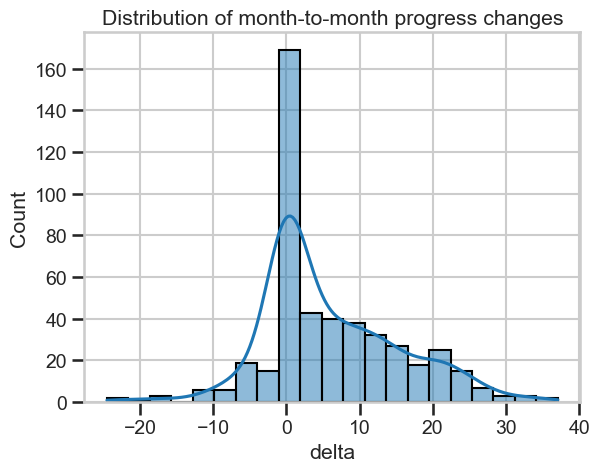

In [6]:
sns.histplot(p["delta"], kde=True)
plt.title("Distribution of month-to-month progress changes")
plt.show()


## 4. Modeling & Feature Selection

### Feature rationale (why these inputs)
Binary flags for **which plan families were open** before the education snapshot; `n_plans` proxies intensity.

### Three-model strategy
1. **Baseline — Mean Δ (dummy):** trivial rule so we never mistake “model” for “signal.”
2. **Interpretable — Ridge regression:** coefficients or clear structure for **explanation** and stakeholder trust.
3. **Performance — Random Forest regressor:** stronger fit for **batch scoring**; may sacrifice some interpretability.

### Feature selection
We keep the feature set **parsimonious** and justified; where helpful, regularization (Ridge / L1) or tree-based implicit selection reduces noise. Final model choice is documented in Section 5 with **tradeoffs**.

---


baseline MAE 7.565746025226993 R2 -0.004325304362124705
ridge MAE 7.565746025226993 R2 -0.004325304362124705
rf MAE 7.569334637542132 R2 -0.004028304725609999


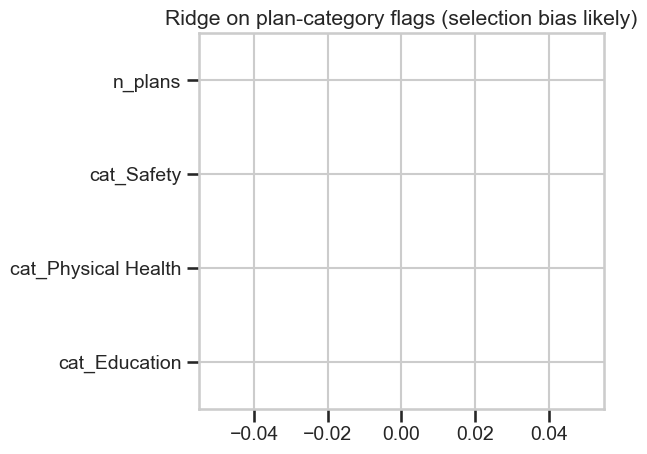

In [7]:
gkf = GroupKFold(5)
for name, m in [("baseline", DummyRegressor(strategy="mean")), ("ridge", Ridge(2.0)), ("rf", RandomForestRegressor(180, max_depth=4, min_samples_leaf=12, random_state=RANDOM_STATE, n_jobs=-1))]:
    sc = cross_validate(pr(m), X, y, cv=gkf, groups=g, scoring={"mae": "neg_mean_absolute_error", "r2": "r2"}, n_jobs=-1)
    print(name, "MAE", -sc["test_mae"].mean(), "R2", sc["test_r2"].mean())
ridge_fit = pr(Ridge(2.0))
ridge_fit.fit(X, y)
coef = pd.Series(ridge_fit.named_steps["m"].coef_, index=feat_cols).sort_values()
coef.plot(kind="barh", title="Ridge on plan-category flags (selection bias likely)")
plt.tight_layout()
plt.show()


## 5. Evaluation & Interpretation

### Metrics
We report metrics appropriate to the task (regression: MAE, RMSE, R²; classification: accuracy, precision, recall, F1, ROC-AUC where applicable). **Grouped or held-out units** (donor, resident, safehouse) avoid optimistic scores when the same entity appears many times.

### What to look for
- **Lift over baseline:** if the interpretable and performance models barely beat the baseline, treat outputs as **weak decision support** until more data arrives.
- **Stability:** cross-validation spread indicates whether the model generalizes or chases noise.

---


## Business Interpretation

### What this means in plain English
Negative mean Δ for a category may mean **harder cases** get that plan—not that the plan **harms** youth.

### How reliable is this for real decisions?
**Low for causal claims**; adequate for **agenda-setting** with clinical leadership.

### What should the organization do differently?
Run **small randomized pilots** before scaling any “drop this plan” decision.

### What decision does this directly support?
**Training curriculum** emphasis and **research questions**.

### When the model is wrong
- **False positives (predicted high risk / high amount / etc., but reality was “fine”):**  
  Think a plan “works” when confounded → misallocate budget.
- **False negatives (model said “low concern” but something important happened):**  
  Discard a useful plan → worse outcomes; mitigate with **mixed-methods** evaluation.

---


## 6. Causal & Relationship Analysis

### What relationships showed up in the data
Category-specific mean deltas and ridge signs are **descriptive**.

### Why these are not proven causal
Selection into plans drives most observed patterns.

### Honest limitations
Synthetic data; single org.

---


## Key Findings

- Lead with **selection bias** in every presentation.
- Use table of **on vs off means** for discussion, not HR scoring.
- RF lift over ridge is **about prediction**, not causality.

---


## Recommended Actions

- Partner with academics for **difference-in-differences** if IDs allow.
- Document **ethical** use: never tie pay to these coefficients alone.

---


## 7. Deployment Plan

### What triggers scoring
**Quarterly** analytic job (not real-time).

### Where results appear in the .NET application
**.NET Admin → Quality dashboard** “Intervention insights” read-only cards (aggregated).

### Who uses the output and how
| **Program QA** | Reviews |
| **Clinical director** | Training |

### PostgreSQL table schema

```sql
CREATE TABLE intervention_effectiveness_snapshot (
  id BIGSERIAL PRIMARY KEY,
  snapshot_quarter DATE NOT NULL,
  plan_category VARCHAR(64) NOT NULL,
  mean_progress_delta DOUBLE PRECISION,
  n_exposures INTEGER,
  model_version VARCHAR(40) NOT NULL,
  scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
  UNIQUE (snapshot_quarter, plan_category, model_version)
);
```

### Example upsert (batch job after training/scoring)

```sql
INSERT INTO intervention_effectiveness_snapshot (snapshot_quarter, plan_category, mean_progress_delta, n_exposures, model_version)
VALUES (DATE '2026-04-01', 'Safety', -0.8, 120, 'intervention_v2')
ON CONFLICT (snapshot_quarter, plan_category, model_version)
DO UPDATE SET mean_progress_delta = EXCLUDED.mean_progress_delta, n_exposures = EXCLUDED.n_exposures, scored_at = NOW();
```

### Python → PostgreSQL → .NET data flow
1. Scheduled **batch job** (e.g., nightly Airflow / Azure Function / Windows Task Scheduler) runs this notebook’s scoring script or a `joblib` loader.
2. Script reads the latest warehouse export or DB replica, builds features **as of `run_date`**, computes predictions.
3. Results are **UPSERTed** into the table below (idempotent per natural key).
4. The **.NET** admin API reads via EF Core or Dapper; UI shows sortable lists, filters, and **no raw model internals** to end users unless “explain” panel is explicitly designed.

Aggregate in Python then upsert; **no per-resident public scores** recommended.

---


In [8]:
from joblib import dump
final = pr(RandomForestRegressor(180, max_depth=4, min_samples_leaf=12, random_state=RANDOM_STATE, n_jobs=-1))
final.fit(X, y)
dump(final, OUTPUT_DIR / "intervention_effect_v2.joblib")


['/Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/ml_pipelines/artifacts/intervention_effect_v2.joblib']